In [ ]:
!pip install upsetplot

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import re
from difflib import SequenceMatcher
from pathlib import Path
from matplotlib.ticker import MaxNLocator
import numpy as np
from difflib import get_close_matches


#drive.mount('/content/drive')
#os.listdir("/content/drive/MyDrive/estudos_snowbaling")
#base = "/content/drive/MyDrive/estudos_snowbaling"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE = Path(".")
CSV_BASE = BASE / "extended_tool_analisy" / "CSVs"

In [ ]:
TOOL_ALIASES = {
    "googleacademico": "googlescholar",
    "googlescholar": "googlescholar",
    "google scholar": "googlescholar",
    "lens": "lens",
    "litmaps": "litmaps",
    "litmap": "litmaps",
    "researchrabbit": "researchrabbit",
    "semanticscholar": "semanticscholar",
    "semantic scholar": "semanticscholar",
    "openalex": "openalex",
    "opencitations": "opencitations",
    "snowmap": "snowmap"
}

ALL_TOOLS = [
    "googlescholar",
    "lens",
    "litmaps",
    "researchrabbit",
    "semanticscholar",
    "openalex",
    "opencitations",
    "snowmap"
]

#normalization
def normalize_doi(x):
    if pd.isna(x):
        return None

    s = str(x).strip().lower()

    if s in {"", "nan", "none", "null", "x"}:
        return None

    s = s.replace("https://doi.org/", "")
    s = s.replace("http://doi.org/", "")
    s = s.replace("https://dx.doi.org/", "")
    s = s.replace("http://dx.doi.org/", "")
    s = s.replace("doi.org/", "")
    s = s.replace("doi:", "")
    s = s.strip()

    # cerca un DOI anche dentro stringhe più lunghe
    m = re.search(r"10\.\S+", s)
    if not m:
        return None

    s = m.group(0)
    s = s.rstrip(" .;,)")
    return s or None

def normalize_title(x):
    if pd.isna(x):
        return None

    s = str(x).strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s]", "", s)
    return s or None

#finding columns
DOI_COL_CANDIDATES = [
    "doi", "DOI", "doi_norm", "document_doi", "paper_doi", "work_doi", "citing", "externalIds"
]

TITLE_COL_CANDIDATES = [
    "title", "Title", "paper_title", "document_title", "article_title",
    "display_name", "work_title", "titulo"
]


def find_doi_column(df):
    cols_lower = {c.lower(): c for c in df.columns}

    for cand in DOI_COL_CANDIDATES:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]

    for c in df.columns:
        if "doi" in c.lower():
            return c

    return None


def find_title_column(df):
    cols_lower = {c.lower(): c for c in df.columns}

    for cand in TITLE_COL_CANDIDATES:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]

    for c in df.columns:
        if "title" in c.lower() or "titulo" in c.lower():
            return c

    return None


#read each csv

def read_csv_with_fallback(csv_path: Path):
    for sep in [",", ";", "\t"]:
        try:
            return pd.read_csv(csv_path, sep=sep)
        except Exception:
            pass

    return pd.read_csv(csv_path)

def prepare_normalized_df(csv_path: Path, verbose=True):
    df = read_csv_with_fallback(csv_path)
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]

    doi_col = find_doi_column(df)
    title_col = find_title_column(df)

    #warning
    if verbose:
        if doi_col is None:
            print(f"[WARNING] {csv_path.name} → colonna DOI NON trovata")
        if title_col is None:
            print(f"[WARNING] {csv_path.name} → colonna TITLE NON trovata")

    if doi_col is not None:
        df["doi_norm"] = df[doi_col].apply(normalize_doi)
    else:
        df["doi_norm"] = None

    if title_col is not None:
        df["title_norm"] = df[title_col].apply(normalize_title)
    else:
        df["title_norm"] = None

    return df, doi_col, title_col


def extract_tool_from_filename(filename):
    stem = Path(filename).stem.lower()
    if "snowmap" in stem:
        return "snowmap"

    # General case: remove "artigoXX_" prefix
    parts = stem.split('_', 1)
    if len(parts) > 1 and parts[0].startswith("artigo"):
        return parts[1]

    # Fallback if no specific pattern matched
    return stem


### **QUARTILE ANALYSIS**


In [ ]:
#reading csv
def read_csv_with_fallback(path):
    try:
        return pd.read_csv(path)
    except pd.errors.ParserError:
        try:
            return pd.read_csv(path, sep=";")
        except Exception:
            return None
    except UnicodeDecodeError:
        try:
            return pd.read_csv(path, encoding="latin1")
        except Exception:
            return None
    except Exception:
        return None


#normalization venue
def normalize_tool_name(name: str) -> str:
    if not isinstance(name, str):
        return ""
    name = name.lower().strip()
    name = name.replace(".csv", "")
    return name


def extract_tool_from_filename(fname: str) -> str:
    fname = fname.lower().strip()
    fname = re.sub(r"^artigo\d+_", "", fname)
    fname = fname.replace(".csv", "")
    return fname


def normalize_venue_name(name: str) -> str:
    if pd.isna(name):
        return None

    name = str(name).lower().strip()
    name = re.sub(r"[^a-z0-9 ]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()

    if not name:
        return None
    return name

#fuzzy match
def find_best_fuzzy_match(venue, candidates, cutoff=0.92):
    """
    venue: stringa normalizzata da cercare
    candidates: iterable di journal normalizzati
    cutoff: soglia di similarità (0-1)
    """
    if not venue:
        return None

    matches = get_close_matches(venue, list(candidates), n=1, cutoff=cutoff)
    return matches[0] if matches else None

from difflib import SequenceMatcher, get_close_matches

#column map
SOURCE_COL_BY_TOOL = {
    "googlescholar": "Source",
    "lens": "Source Title",
    "litmaps": "Journal",
    "researchrabbit": "Journal",
    "openalex": "primary_location.source.display_name",
    "semanticscholar": "venue",
    "opencitations": None,
    "snowmap": "Venue"
}


#load sjr and jcr
def load_sjr_jcr(sjr_path, jcr_path):
    sjr = read_csv_with_fallback(sjr_path)
    jcr = read_csv_with_fallback(jcr_path)

    if sjr is None or jcr is None:
        raise ValueError("Errore nel caricamento di SJR o JCR")

    sjr.columns = [c.lower().strip() for c in sjr.columns]
    jcr.columns = [c.lower().strip() for c in jcr.columns]

    return sjr, jcr


#mapping match
def build_journal_maps(sjr, jcr):
    sjr_map = {}
    jcr_map = {}

    #sjr
    sjr_title_col = None
    sjr_quart_col = None

    for cand in ["title", "source title", "journal name"]:
        if cand in sjr.columns:
            sjr_title_col = cand
            break

    for cand in ["sjr best quartile", "sjr_best_quartile", "best quartile", "quartile"]:
        if cand in sjr.columns:
            sjr_quart_col = cand
            break

    if sjr_title_col and sjr_quart_col:
        for _, row in sjr.iterrows():
            name = normalize_venue_name(row.get(sjr_title_col))
            quartile = row.get(sjr_quart_col)

            if name and pd.notna(quartile):
                sjr_map[name] = str(quartile).strip()

    #jcr
    jcr_title_col = None
    jcr_quart_col = None

    for cand in ["journal name", "title", "source title"]:
        if cand in jcr.columns:
            jcr_title_col = cand
            break

    for cand in ["jif quartile", "quartile"]:
        if cand in jcr.columns:
            jcr_quart_col = cand
            break

    if jcr_title_col and jcr_quart_col:
        for _, row in jcr.iterrows():
            name = normalize_venue_name(row.get(jcr_title_col))
            quartile = row.get(jcr_quart_col)

            if name and pd.notna(quartile):
                jcr_map[name] = str(quartile).strip()

    return sjr_map, jcr_map

#match quartile
def get_quartile_with_match_type(venue, sjr_map, jcr_map, use_fuzzy=True, fuzzy_cutoff=0.92):
    v = normalize_venue_name(venue)

    if not v:
        return "-", "missing"

    if v in sjr_map:
        return sjr_map[v], "exact_sjr"

    if v in jcr_map:
        return jcr_map[v], "exact_jcr"

    if use_fuzzy:
        best_sjr = find_best_fuzzy_match(v, sjr_map.keys(), cutoff=fuzzy_cutoff)
        if best_sjr:
            return sjr_map[best_sjr], "fuzzy_sjr"

        best_jcr = find_best_fuzzy_match(v, jcr_map.keys(), cutoff=fuzzy_cutoff)
        if best_jcr:
            return jcr_map[best_jcr], "fuzzy_jcr"

    return "No match", "no_match"

#analysis file
def analyze_quartiles_in_file(csv_path, sjr_map, jcr_map, verbose=False):
    df = read_csv_with_fallback(csv_path)

    if df is None or df.empty:
        if verbose:
            print(f"[SKIP] File vuoto o non leggibile: {csv_path.name}")
        return None

    tool = normalize_tool_name(extract_tool_from_filename(csv_path.name))
    source_col = SOURCE_COL_BY_TOOL.get(tool)

    if source_col is None:
        if verbose:
            print(f"[SKIP] {csv_path.name}: nessuna colonna source definita per tool={tool}")
        return None

    if source_col not in df.columns:
        if verbose:
            print(f"[SKIP] {csv_path.name}: colonna '{source_col}' non trovata")
            print("Colonne disponibili:", list(df.columns))
        return None

    quartiles = []
    match_types = []

    for val in df[source_col]:
        q, mt = get_quartile_with_match_type(val, sjr_map, jcr_map, use_fuzzy=True, fuzzy_cutoff=0.92)
        quartiles.append(q)
        match_types.append(mt)

    quartile_counter = Counter(quartiles)
    matchtype_counter = Counter(match_types)

    if verbose:
        print(f"\n[OK] {csv_path.name} | tool={tool}")
        print("Quartili:", dict(quartile_counter))
        print("Tipi di match:", dict(matchtype_counter))

    return {
        "quartiles": quartile_counter,
        "match_types": matchtype_counter
    }

#analysis folder
def analyze_quartiles_in_folder(folder_path, sjr_map, jcr_map, verbose=False):
    results = {}

    for csv_path in Path(folder_path).glob("*.csv"):
        tool = normalize_tool_name(extract_tool_from_filename(csv_path.name))
        counter = analyze_quartiles_in_file(csv_path, sjr_map, jcr_map, verbose=verbose)

        if counter is not None:
            results[tool] = counter

    return results


#building the table
def build_quartile_table(results_dict):
    all_quartiles = ["Q1", "Q2", "Q3", "Q4", "No match", "-"]

    if not results_dict:
        return pd.DataFrame(0, index=all_quartiles, columns=[])

    df = pd.DataFrame(0, index=all_quartiles, columns=sorted(results_dict.keys()))

    for tool, result in results_dict.items():
        if isinstance(result, dict) and "quartiles" in result:
            counter = result["quartiles"]
        else:
            counter = result

        for q, count in counter.items():
            q_clean = str(q).strip()

            if q_clean in df.index:
                df.loc[q_clean, tool] = count
            else:
                print(f"[WARN] quartile non riconosciuto: {q_clean} per tool={tool}")

    return df


#preparation for plot
def prepare_quartile_plot_df_from_table(quartile_df, slr_name):
    rows = []

    for quartile in quartile_df.index:
        for tool in quartile_df.columns:
            rows.append({
                "SLR": slr_name,
                "tool": tool,
                "quartile": quartile,
                "count": quartile_df.loc[quartile, tool]
            })

    return pd.DataFrame(rows)


def combine_quartile_plot_dfs(*dfs):
    valid = [df for df in dfs if df is not None and not df.empty]
    if not valid:
        return pd.DataFrame(columns=["SLR", "tool", "quartile", "count"])
    return pd.concat(valid, ignore_index=True)

In [ ]:
SJR_PATH = CSV_BASE / "quartile/sjr_data.csv"
JCR_PATH = CSV_BASE /"quartile/jcr_data.csv"
#SJR_PATH = Path("/content/drive/MyDrive/estudos_snowbaling/quartile/sjr_data.csv")
#JCR_PATH = Path("/content/drive/MyDrive/estudos_snowbaling/quartile/jcr_data.csv")

folder1 = CSV_BASE / "new_csvs_slr01"
folder2 = CSV_BASE / "new_csvs_slr02"
folder3 = CSV_BASE / "new_csvs_slr03"
folder4 = CSV_BASE / "new_csvs_slr04"
#folder1 = Path("/content/drive/MyDrive/estudos_snowbaling/new_csvs_slr01")
#folder2 = Path("/content/drive/MyDrive/estudos_snowbaling/new_csvs_slr02")
#folder3 = Path("/content/drive/MyDrive/estudos_snowbaling/new_csvs_slr03")
#folder4 = Path("/content/drive/MyDrive/estudos_snowbaling/new_csvs_slr04")

sjr, jcr = load_sjr_jcr(SJR_PATH, JCR_PATH)
sjr_map, jcr_map = build_journal_maps(sjr, jcr)

res1 = analyze_quartiles_in_folder(folder1, sjr_map, jcr_map, verbose=True)
q1 = build_quartile_table(res1)
plot_q1 = prepare_quartile_plot_df_from_table(q1, "SLR 1")

res2 = analyze_quartiles_in_folder(folder2, sjr_map, jcr_map, verbose=True)
q2 = build_quartile_table(res2)
plot_q2 = prepare_quartile_plot_df_from_table(q2, "SLR 2")

res3 = analyze_quartiles_in_folder(folder3, sjr_map, jcr_map, verbose=True)
q3 = build_quartile_table(res3)
plot_q3 = prepare_quartile_plot_df_from_table(q3, "SLR 3")

res4 = analyze_quartiles_in_folder(folder4, sjr_map, jcr_map, verbose=True)
q4 = build_quartile_table(res4)
plot_q4 = prepare_quartile_plot_df_from_table(q4, "SLR 4")

quartile_all_df = combine_quartile_plot_dfs(plot_q1, plot_q2, plot_q3, plot_q4)

display(q1)
display(plot_q1)
display(quartile_all_df)


[OK] artigo01_litmaps.csv | tool=litmaps
Quartili: {'No match': 75, 'Q1': 14, 'Q4': 1, 'Q2': 1}
Tipi di match: {'no_match': 75, 'exact_sjr': 15, 'fuzzy_sjr': 1}

[OK] artigo01_openAlex.csv | tool=openalex
Quartili: {'Q1': 15, '-': 36, 'No match': 15, 'Q2': 1, 'Q4': 1}
Tipi di match: {'exact_sjr': 17, 'missing': 36, 'no_match': 15}
[SKIP] artigo01_openCitations.csv: nessuna colonna source definita per tool=opencitations

[OK] artigo01_researchRabbit.csv | tool=researchrabbit
Quartili: {'Q1': 19, 'No match': 88, 'Q2': 3, 'Q4': 1}
Tipi di match: {'exact_sjr': 22, 'no_match': 88, 'fuzzy_sjr': 1}

[OK] artigo01_googleScholar.csv | tool=googlescholar
Quartili: {'Q1': 6, 'No match': 90, '-': 25, 'Q3': 1}
Tipi di match: {'exact_sjr': 7, 'no_match': 90, 'missing': 25}

[OK] artigo01_semanticScholar.csv | tool=semanticscholar
Quartili: {'Q1': 19, 'No match': 62, 'Q2': 3, 'Q4': 1, '-': 23}
Tipi di match: {'exact_sjr': 21, 'no_match': 62, 'fuzzy_sjr': 2, 'missing': 23}

[OK] artigo01_lens.csv | t

,googlescholar,lens,litmaps,openalex,researchrabbit,semanticscholar,snowmap
Q1,6,13,14,15,19,19,20
Q2,0,1,1,1,3,3,3
Q3,1,0,0,0,0,0,0
Q4,0,0,1,1,1,1,1
No match,90,40,75,15,88,62,67
-,25,2,0,36,0,23,7


,SLR,tool,quartile,count
0,SLR 1,googlescholar,Q1,6
1,SLR 1,lens,Q1,13
2,SLR 1,litmaps,Q1,14
3,SLR 1,openalex,Q1,15
4,SLR 1,researchrabbit,Q1,19
5,SLR 1,semanticscholar,Q1,19
6,SLR 1,snowmap,Q1,20
7,SLR 1,googlescholar,Q2,0
8,SLR 1,lens,Q2,1
9,SLR 1,litmaps,Q2,1


,SLR,tool,quartile,count
0,SLR 1,googlescholar,Q1,6
1,SLR 1,lens,Q1,13
2,SLR 1,litmaps,Q1,14
3,SLR 1,openalex,Q1,15
4,SLR 1,researchrabbit,Q1,19
...,...,...,...,...
157,SLR 4,lens,-,1
158,SLR 4,openalex,-,8
159,SLR 4,researchrabbit,-,0
160,SLR 4,semanticscholar,-,0


In [ ]:
display(q1)
display(q2)
display(q3)
display(q4)

,googlescholar,lens,litmaps,openalex,researchrabbit,semanticscholar,snowmap
Q1,6,13,14,15,19,19,20
Q2,0,1,1,1,3,3,3
Q3,1,0,0,0,0,0,0
Q4,0,0,1,1,1,1,1
No match,90,40,75,15,88,62,67
-,25,2,0,36,0,23,7


,googlescholar,lens,litmaps,openalex,researchrabbit,semanticscholar,snowmap
Q1,11,4,13,13,15,14,15
Q2,5,5,7,6,7,5,7
Q3,0,0,0,0,0,0,0
Q4,0,1,1,1,1,0,0
No match,23,3,10,2,11,8,10
-,8,0,0,4,0,4,3


,googlescholar,lens,litmaps,openalex,researchrabbit,semanticscholar,snowmap
Q1,29,61,28,61,66,55,58
Q2,9,22,10,26,15,13,15
Q3,1,7,3,7,6,5,5
Q4,3,6,2,7,3,2,2
No match,210,91,105,48,142,111,122
-,51,8,5,73,5,25,14


,googlescholar,lens,openalex,researchrabbit,semanticscholar,snowmap
Q1,0,1,1,1,1,1
Q2,0,0,0,0,0,0
Q3,0,0,0,0,0,0
Q4,0,2,2,1,0,0
No match,18,6,2,9,7,7
-,3,1,8,0,0,0


In [ ]:
#function for graph
def plot_quartile_results_2x2(q1, q2, q3, q4):
    quartile_order = ["Q1", "Q2", "Q3", "Q4", "No match", "-"]

    slr_tables = {
        "SLR 1": q1.copy(),
        "SLR 2": q2.copy(),
        "SLR 3": q3.copy(),
        "SLR 4": q4.copy(),
    }

    tool_order = [
        "googlescholar",
        "lens",
        "openalex",
        "opencitations",
        "semanticscholar",
        "litmaps",
        "researchrabbit",
        "snowmap"
    ]

    for slr, df in slr_tables.items():
        df = df.copy()
        df.index = [str(i).strip() for i in df.index]
        df = df.reindex(quartile_order).fillna(0)
        df.columns = [str(c).strip().lower() for c in df.columns]
        df = df.reindex(columns=tool_order, fill_value=0)
        slr_tables[slr] = df
    fig, axes = plt.subplots(
        2, 2,
        figsize=(16, 8.5),
        sharey=False
    )
    axes = axes.flatten()

    x = np.arange(len(quartile_order))
    n_tools = len(tool_order)
    group_w = 0.82
    bar_w = group_w / max(n_tools, 1)

    handles = None
    labels = None

    for ax, slr in zip(axes, ["SLR 1", "SLR 2", "SLR 3", "SLR 4"]):
        pv = slr_tables[slr]

        for i, tool in enumerate(tool_order):
            y = pv[tool].values.astype(float)

            ax.bar(
                x - group_w / 2 + i * bar_w + bar_w / 2,
                y,
                width=bar_w,
                edgecolor="white",
                linewidth=0,
                label=tool
            )

        ax.set_title(slr, fontsize=13, fontweight="bold", pad=6)
        ax.set_xticks(x)
        ax.set_xticklabels(quartile_order, rotation=15, ha="right", fontsize=13, color="black")
        ax.tick_params(axis="y", labelsize=11, color="black")

        ax.grid(axis="y", linestyle="--", alpha=0.35)
        ax.grid(axis="x", visible=False)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))



        if handles is None:
            handles, labels = ax.get_legend_handles_labels()

    axes[0].set_ylabel("Number of Articles", fontsize=11)
    axes[2].set_ylabel("Number of Articles", fontsize=11)

    fig.legend(
        handles,
        labels,
        title="Tool",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.05),
        ncol=8,
        frameon=False
    )

    plt.tight_layout()
    plt.show()

In [ ]:
TOOL_ORDER = [
    "googlescholar",
    "lens",
    "openalex",
    "opencitations",
    "semanticscholar",
    "litmaps",
    "researchrabbit",
    "snowmap"
]

QUARTILE_ORDER = ["Q1", "Q2", "Q3", "Q4", "No match", "-"]

palette = plt.get_cmap("tab10")
TOOL_COLORS = {tool: palette(i) for i, tool in enumerate(TOOL_ORDER)}
def plot_quartile_results_2x2(q1, q2, q3, q4):
    slr_tables = {
        "SLR 1": q1.copy(),
        "SLR 2": q2.copy(),
        "SLR 3": q3.copy(),
        "SLR 4": q4.copy(),
    }

    fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharey=False)
    axes = axes.flatten()

    handles, labels = None, None

    for ax, (slr, df) in zip(axes, slr_tables.items()):
        df = df.copy()

        df.index = [str(i).strip() for i in df.index]
        df = df.reindex(QUARTILE_ORDER).fillna(0)

        df.columns = [str(c).strip().lower() for c in df.columns]
        df = df.reindex(columns=TOOL_ORDER, fill_value=0)

        df.plot(
            kind="bar",
            ax=ax,
            color=[TOOL_COLORS[t] for t in TOOL_ORDER],
            width=0.82
        )

        ax.set_title(slr, fontsize=14, fontweight="bold", pad=6)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(QUARTILE_ORDER, rotation=15, ha="right", fontsize=12, color="black")

        ax.tick_params(axis="y", labelsize=11, colors="black")
        ax.tick_params(axis="x", colors="black")

        ax.grid(axis="y", linestyle="--", alpha=0.35)
        ax.grid(axis="x", visible=False)

        if handles is None:
            handles, labels = ax.get_legend_handles_labels()

        if ax.get_legend() is not None:
            ax.get_legend().remove()

    axes[0].set_ylabel("Number of Articles", fontsize=12, color="black")
    axes[2].set_ylabel("Number of Articles", fontsize=12, color="black")

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=8,
        title="Tool",
        bbox_to_anchor=(0.5, 1.05),
        frameon=False
    )

    plt.tight_layout()
    plt.show()

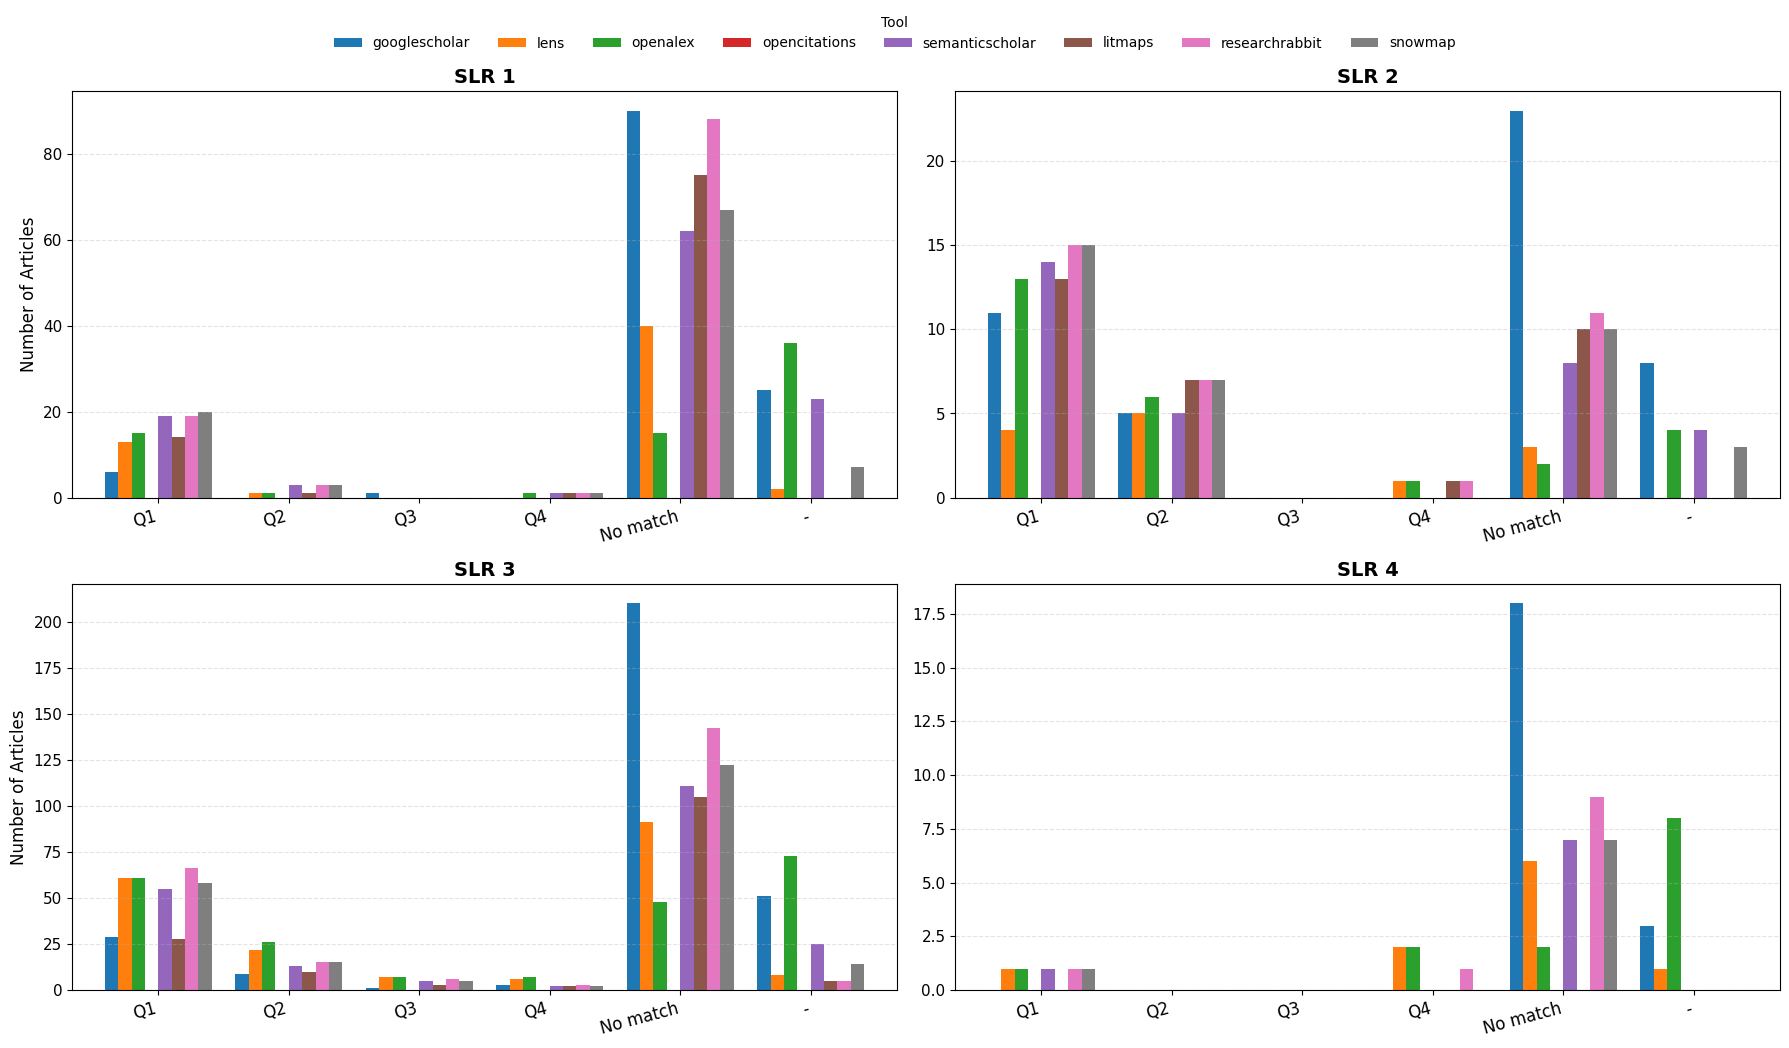

In [ ]:
plot_quartile_results_2x2(q1, q2, q3, q4)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

palette = plt.get_cmap("tab10")
TOOL_COLORS = {tool: palette(i) for i, tool in enumerate(TOOL_ORDER)}

def plot_quartile_results_2x2_percent(q1, q2, q3, q4):
    slr_tables = {
        "SLR 1": q1.copy(),
        "SLR 2": q2.copy(),
        "SLR 3": q3.copy(),
        "SLR 4": q4.copy(),
    }

    fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharey=False)
    axes = axes.flatten()

    handles, labels = None, None

    for ax, (slr, df) in zip(axes, slr_tables.items()):
        df = df.copy()

        df.index = [str(i).strip() for i in df.index]
        df = df.reindex(QUARTILE_ORDER).fillna(0)

        df.columns = [str(c).strip().lower() for c in df.columns]
        df = df.reindex(columns=TOOL_ORDER, fill_value=0)


        df = df.apply(pd.to_numeric, errors="coerce").fillna(0)

        col_sums = df.sum(axis=0).replace(0, np.nan)
        df_pct = df.div(col_sums, axis=1) * 100
        df_pct = df_pct.fillna(0)

        df_pct.plot(
            kind="bar",
            ax=ax,
            color=[TOOL_COLORS[t] for t in TOOL_ORDER],
            width=0.82
        )

        ax.set_title(slr, fontsize=14, fontweight="bold", pad=6)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(QUARTILE_ORDER, rotation=15, ha="right", fontsize=12, color="black")

        ax.tick_params(axis="y", labelsize=11, colors="black")
        ax.tick_params(axis="x", colors="black")

        ax.grid(axis="y", linestyle="--", alpha=0.35)
        ax.grid(axis="x", visible=False)

        ax.set_ylim(0, 100)
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

        if handles is None:
            handles, labels = ax.get_legend_handles_labels()

        if ax.get_legend() is not None:
            ax.get_legend().remove()

    axes[0].set_ylabel("Percentage of Articles", fontsize=12, color="black")
    axes[2].set_ylabel("Percentage of Articles", fontsize=12, color="black")

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=8,
        title="Tool",
        bbox_to_anchor=(0.5, 1.05),
        frameon=False
    )

    plt.tight_layout()
    plt.show()

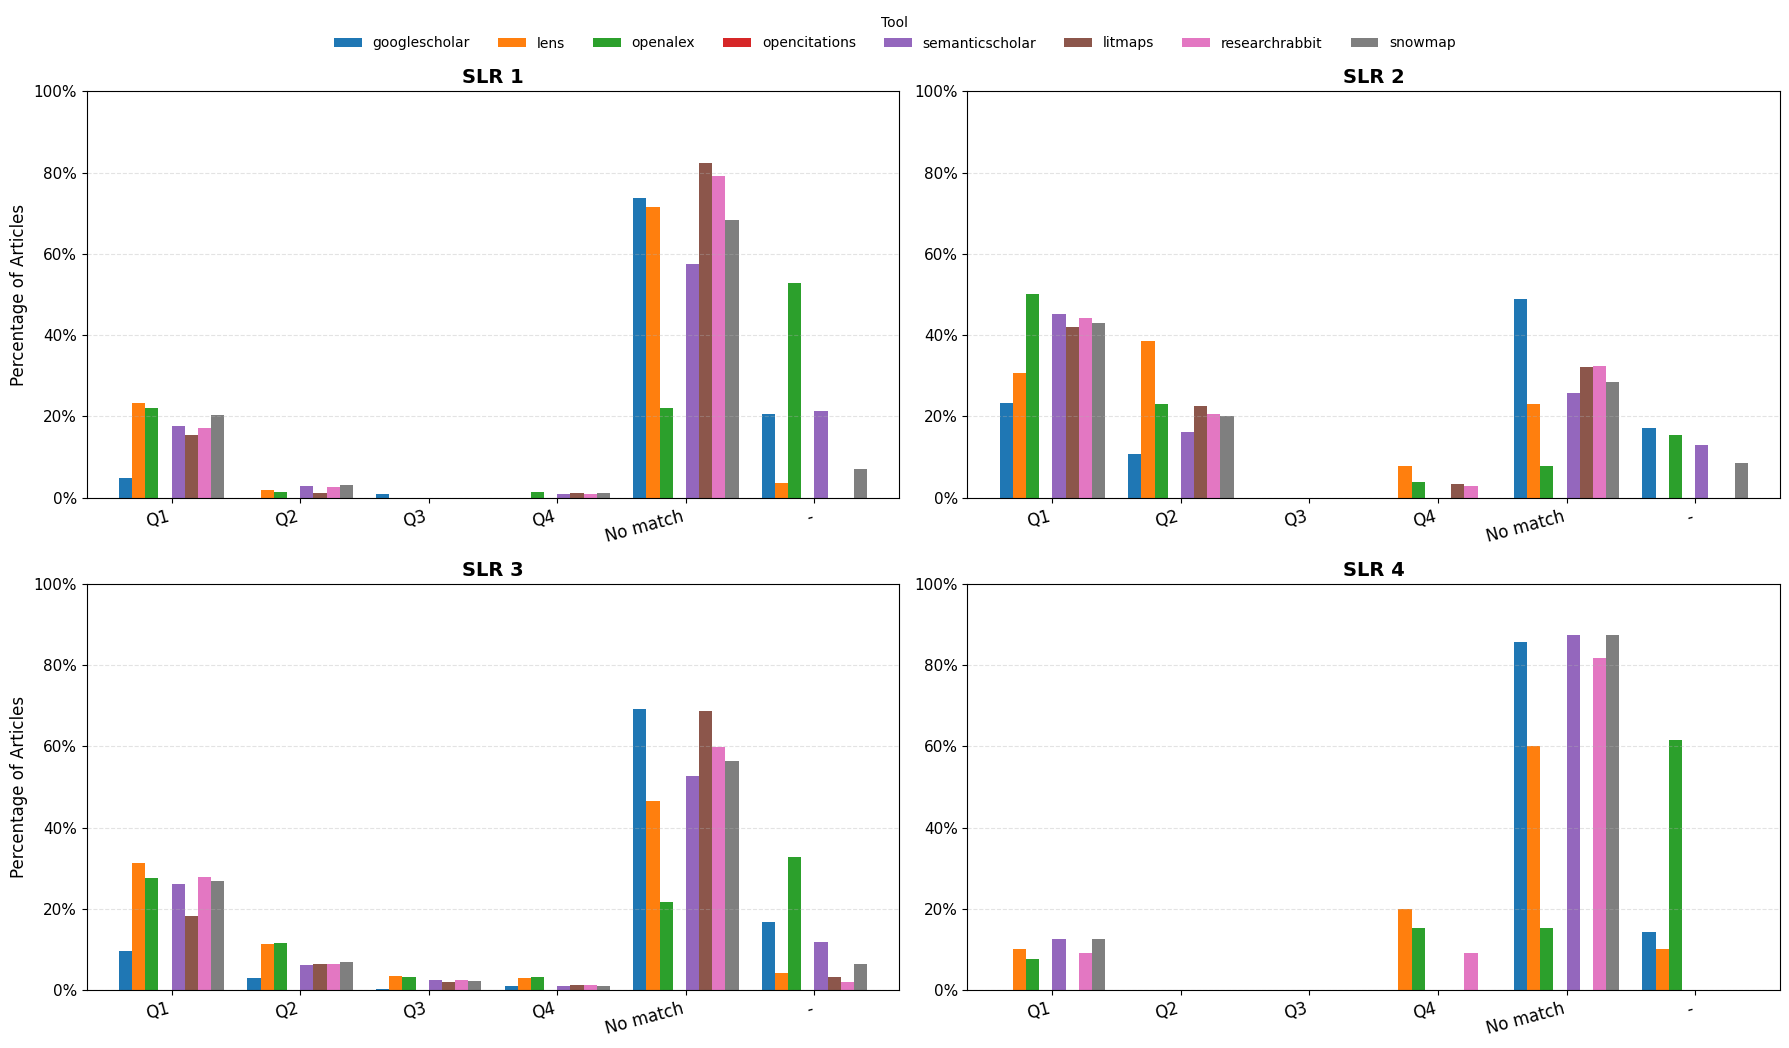

In [ ]:
plot_quartile_results_2x2_percent(q1, q2, q3, q4)